In [1]:
# Imports

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import os
import numpy as np


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Dataset Path

dataset_path = "/content/drive/MyDrive/Final_Dataset"

print(os.listdir(dataset_path))

['Tomato___Late_blight', 'Tomato____Early_blight', 'Tomato___healthy', 'Potato____healthy', 'Potato____Early_blight', 'Potato___Late_blight']


DATA PREPROCESSING

In [4]:
 # Data Generator (rescale + validation split)

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [5]:
# Training Data

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)


Found 5323 images belonging to 6 classes.


In [6]:
# Validation Data

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 1329 images belonging to 6 classes.


In [7]:
# Check classes

print("Classes:", train_data.class_indices)

Classes: {'Potato___Late_blight': 0, 'Potato____Early_blight': 1, 'Potato____healthy': 2, 'Tomato___Late_blight': 3, 'Tomato____Early_blight': 4, 'Tomato___healthy': 5}


 MODEL 1 = CNN (Convolutional Neural Network)

In [8]:
# Build + Compile + Train (All in One)

model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dense(train_data.num_classes, activation='softmax')
])

# Compile
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
167/167 ━━━━━━━━━━━━━━━━━━━━ 1276s 8s/step - accuracy: 0.6737 - loss: 1.0767 - val_accuracy: 0.8698 - val_loss: 0.3773
Epoch 2/20
167/167 ━━━━━━━━━━━━━━━━━━━━ 28s 167ms/step - accuracy: 0.8687 - loss: 0.3592 - val_accuracy: 0.8457 - val_loss: 0.3894
Epoch 3/20
167/167 ━━━━━━━━━━━━━━━━━━━━ 28s 165ms/step - accuracy: 0.9324 - loss: 0.1957 - val_accuracy: 0.8826 - val_loss: 0.3332
Epoch 4/20
167/167 ━━━━━━━━━━━━━━━━━━━━ 28s 167ms/step - accuracy: 0.9707 - loss: 0.0932 - val_accuracy: 0.9029 - val_loss: 0.2848
Epoch 5/20
167/167 ━━━━━━━━━━━━━━━━━━━━ 28s 166ms/step - accuracy: 0.9867 - loss: 0.0475 - val_accuracy: 0.8924 - val_loss: 0.3568
Epoch 6/20
167/167 ━━━━━━━━━━━━━━━━━━━━ 28s 167ms/step - accuracy: 0.9955 - loss: 0.0197 - val_accuracy: 0.8766 - val_loss: 0.4204
Epoch 7/20
167/167 ━━━━━━━━━━━━━━━━━━━━ 28s 166ms/step - accuracy: 0.9947 - loss: 0.0177 - val_accuracy: 0.8646 - val_loss: 0.4884
Epoch 8/20
167/167 ━━━━━━━━━━━━━━━━━━━━ 27s 164ms/step - accuracy: 0.9929 - loss: 0.

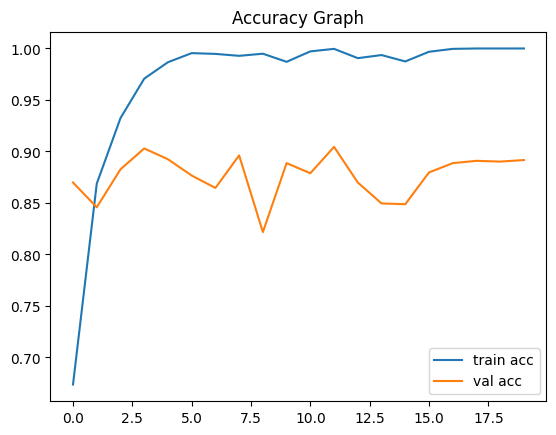

In [9]:
# Accuracy Graph

plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.title("Accuracy Graph")
plt.show()

MODEL 2  = MobileNetV2


In [10]:
# MobileNetV2

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

# Freeze layers
base_model.trainable = False

model2 = tf.keras.models.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(train_data.num_classes, activation='softmax')
])

model2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model2.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
167/167 ━━━━━━━━━━━━━━━━━━━━ 74s 339ms/step - accuracy: 0.8702 - loss: 0.3572 - val_accuracy: 0.9421 - val_loss: 0.1594
Epoch 2/5
167/167 ━━━━━━━━━━━━━━━━━━━━ 30s 180ms/step - accuracy: 0.9502 - loss: 0.1415 - val_accuracy: 0.9496 - val_loss: 0.1439
Epoch 3/5
167/167 ━━━━━━━━━━━━━━━━━━━━ 29s 176ms/step - accuracy: 0.9696 - loss: 0.0964 - val_accuracy: 0.9579 - val_loss: 0.1182
Epoch 4/5
167/167 ━━━━━━━━━━━━━━━━━━━━ 28s 167ms/step - accuracy: 0.9758 - loss: 0.0718 - val_accuracy: 0.9436 - val_loss: 0.1501
Epoch 5/5
167/167 ━━━━━━━━━━━━━━━━━━━━ 28s 167ms/step - accuracy: 0.9844 - loss: 0.0505 - val_accuracy: 0.9466 - val_loss: 0.1397


MODEL 3 = ResNet50


In [11]:
# ResNet50

base_model = tf.keras.applications.ResNet50(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model3 = tf.keras.models.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(train_data.num_classes, activation='softmax')
])

model3.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history3 = model3.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
167/167 ━━━━━━━━━━━━━━━━━━━━ 54s 248ms/step - accuracy: 0.3836 - loss: 1.5539 - val_accuracy: 0.5372 - val_loss: 1.3864
Epoch 2/5
167/167 ━━━━━━━━━━━━━━━━━━━━ 29s 174ms/step - accuracy: 0.5144 - loss: 1.3090 - val_accuracy: 0.5245 - val_loss: 1.2080
Epoch 3/5
167/167 ━━━━━━━━━━━━━━━━━━━━ 28s 169ms/step - accuracy: 0.5720 - loss: 1.1639 - val_accuracy: 0.5952 - val_loss: 1.0980
Epoch 4/5
167/167 ━━━━━━━━━━━━━━━━━━━━ 29s 171ms/step - accuracy: 0.6297 - loss: 1.0344 - val_accuracy: 0.7118 - val_loss: 0.9446
Epoch 5/5
167/167 ━━━━━━━━━━━━━━━━━━━━ 28s 170ms/step - accuracy: 0.6547 - loss: 0.9454 - val_accuracy: 0.6403 - val_loss: 0.9052


COMMPARISION GRAPH

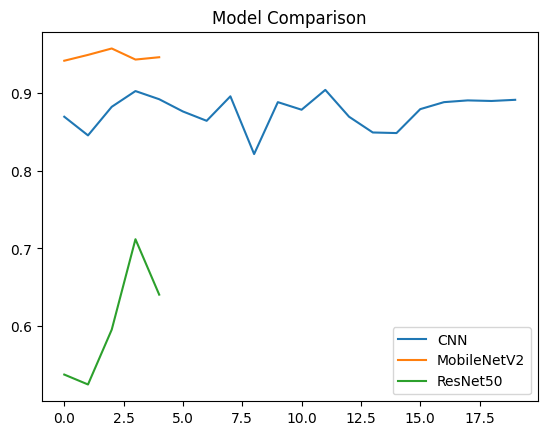

In [12]:
#  Comparision Graph

plt.plot(history.history['val_accuracy'], label='CNN')
plt.plot(history2.history['val_accuracy'], label='MobileNetV2')
plt.plot(history3.history['val_accuracy'], label='ResNet50')

plt.legend()
plt.title("Model Comparison")
plt.show()

SELECT BEST  MODEL




In [13]:
# Get max validation accuracy of each model
cnn_acc = max(history.history['val_accuracy'])
mobilenet_acc = max(history2.history['val_accuracy'])
resnet_acc = max(history3.history['val_accuracy'])

print("CNN Accuracy:", cnn_acc)
print("MobileNet Accuracy:", mobilenet_acc)
print("ResNet Accuracy:", resnet_acc)

# Find best model
best_acc = max(cnn_acc, mobilenet_acc, resnet_acc)

if best_acc == cnn_acc:
    best_model = model
    model_name = "CNN"
elif best_acc == mobilenet_acc:
    best_model = model2
    model_name = "MobileNetV2"
else:
    best_model = model3
    model_name = "ResNet50"

print("Best Model:", model_name)

# Save best model
best_model.save("best_model.h5")

CNN Accuracy: 0.9044394493103027
MobileNet Accuracy: 0.9578630328178406
ResNet Accuracy: 0.7118133902549744
Best Model: MobileNetV2


MODEL SAVE

In [14]:
from google.colab import files
files.download("best_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

UPLOAD IMAGE

In [15]:
# Image Upload

from google.colab import files
uploaded = files.upload()

Saving 1cd053f6-0016-4680-a924-af15aecd7fb2___RS_LB 4414.JPG to 1cd053f6-0016-4680-a924-af15aecd7fb2___RS_LB 4414.JPG


In [16]:
print(uploaded.keys())

dict_keys(['1cd053f6-0016-4680-a924-af15aecd7fb2___RS_LB 4414.JPG'])


PREDICTION

In [17]:
# Prediction (Test Images )

from tensorflow.keras.preprocessing import image
import numpy as np

#  AUTOMATIC FILE PICK
file_name = list(uploaded.keys())[0]

print("Using file:", file_name)

# IMAGE LOAD
img = image.load_img(file_name, target_size=(224,224))

# PREPROCESS
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

# PREDICT
pred = model.predict(img_array)

# CLASS NAME
class_names = list(train_data.class_indices.keys())
pred_class = class_names[np.argmax(pred)]

print("Prediction:", pred_class)

Using file: 1cd053f6-0016-4680-a924-af15aecd7fb2___RS_LB 4414.JPG
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 888ms/step
Prediction: Potato___Late_blight


In [18]:
# prediction if more than 1 image select

# for file_name in uploaded.keys():
#     print("\nImage:", file_name)

#     img = image.load_img(file_name, target_size=(224,224))
#     img_array = image.img_to_array(img)/255.0
#     img_array = np.expand_dims(img_array, axis=0)

#     pred = model.predict(img_array)
#     pred_class = class_names[np.argmax(pred)]

#     print("Prediction:", pred_class)